<div style="position:relative;overflow:hidden;padding:58px 42px 56px;border-radius:28px;background:radial-gradient(circle at 14% 8%,rgba(56,189,248,.28),transparent 28%),radial-gradient(circle at 92% 92%,rgba(245,158,11,.26),transparent 30%),linear-gradient(132deg,#061827 0%,#0c4a6e 42%,#0f766e 73%,#713f12 128%);color:white;border:1px solid rgba(125,211,252,.34);box-shadow:0 24px 60px rgba(14,116,144,.28)">
  <h1 style="font-size:48px;line-height:1.03;margin:0;letter-spacing:-.04em;color:#f8fafc">The Soil Remembers Rain</h1>
  <div style="position:absolute;right:-38px;bottom:-70px;width:220px;height:220px;border-radius:999px;border:38px solid rgba(255,255,255,.055)"></div>
</div>


In [1]:
import hashlib, importlib.metadata, subprocess, sys, tarfile, warnings
from pathlib import Path
from IPython import get_ipython
shell = get_ipython()
if shell is not None: shell.run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
SOIL, RAIN, LEAF, SUN, NIGHT, ROSE, MIST = "#8a5a2b", "#0891b2", "#0f766e", "#f59e0b", "#172554", "#e11d48", "#e0f2fe"
required = (1, 32, 2)
try:
    installed = tuple(int(x) for x in importlib.metadata.version("kaggle-environments").split(".")[:3])
except Exception: installed = (0, 0, 0)
if installed < required:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "kaggle-environments==1.32.2"], check=True)
import kaggle_environments
from kaggle_environments import make
assert tuple(int(x) for x in kaggle_environments.__version__.split(".")[:3]) >= required
print("official simulator", kaggle_environments.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 30.1 MB/s eta 0:00:00


OpenSpiel exception: Unknown game 'capture_the_flag'. Available games are:
2048
add_noise
amazons
amazons_proxy
ant_foraging_arena
antichess
backgammon
backgammon_proxy
banqi
bargaining
bargaining_proxy
battleship
blackjack
blotto
breakthrough
bridge
bridge_arena
bridge_uncontested_bidding
cached_tree
catch
checkers
chess
chinese_checkers
cliff_walking
clobber
clobber_proxy
coin_game
coin_game_arena
colored_trails
connect_four
coop_box_pushing
coop_to_1p
coordinated_mp
crazy_eights
crazyhouse
cribbage
cursor_go
dark_chess
dark_hex
dark_hex_ir
deep_sea
dots_and_boxes
dots_and_boxes_proxy
dou_dizhu
efg_game
einstein_wurfelt_nicht
euchre
first_sealed_auction
gin_rummy
gin_rummy_proxy
go
gomoku
goofspiel
hanabi
havannah
havannah_proxy
hearts
hex
hive
kriegspiel
kuhn_poker
laser_tag
latent_ttt
leduc_poker
lewis_signaling
liars_dice
liars_dice_ir
lines_of_action
lines_of_action_proxy
maedn
mancala
mancala_proxy
markov_soccer
matching_pennies_3p
matrix_bos
matrix_brps
matrix_cd
matrix_coordin

[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 40.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: OpenSpiel games skipped: 1.
official simulator 1.32.2


OpenSpiel exception: Unknown game 'capture_the_flag'. Available games are:
2048
add_noise
amazons
amazons_proxy
ant_foraging_arena
antichess
backgammon
backgammon_proxy
banqi
bargaining
bargaining_proxy
battleship
blackjack
blotto
breakthrough
breakthrough_proxy
bridge
bridge_arena
bridge_uncontested_bidding
cached_tree
catch
chat_game
checkers
checkers_proxy
chess
chinese_checkers
cliff_walking
clobber
clobber_proxy
coin_game
coin_game_arena
coin_game_proxy
colored_trails
connect_four
connect_four_proxy
coop_box_pushing
coop_to_1p
coordinated_mp
crazy_eights
crazyhouse
cribbage
cursor_go
dark_chess
dark_hex
dark_hex_ir
dark_hex_proxy
deep_sea
dots_and_boxes
dots_and_boxes_proxy
dou_dizhu
efg_game
einstein_wurfelt_nicht
euchre
first_sealed_auction
gin_rummy
gin_rummy_proxy
go
go_proxy
gomoku
goofspiel
hanabi
havannah
havannah_proxy
hearts
hex
hive
hive_proxy
kriegspiel
kuhn_poker
laser_tag
latent_ttt
leduc_poker
lewis_signaling
liars_dice
liars_dice_ir
lines_of_action
lines_of_action_p

## 1. Begin with the losses

Soil V4 did not have one failure mode. Its eleven completed public losses split into seat effects, market-timing variants, production schedules, and a repeated physical defect: pasture construction requested on a visible weed. Treating every loss as “sell more” would have mixed incompatible repairs.

The chart is a server-replay inventory, not a local score estimate. It is shown before the new agent so the design remains falsifiable.


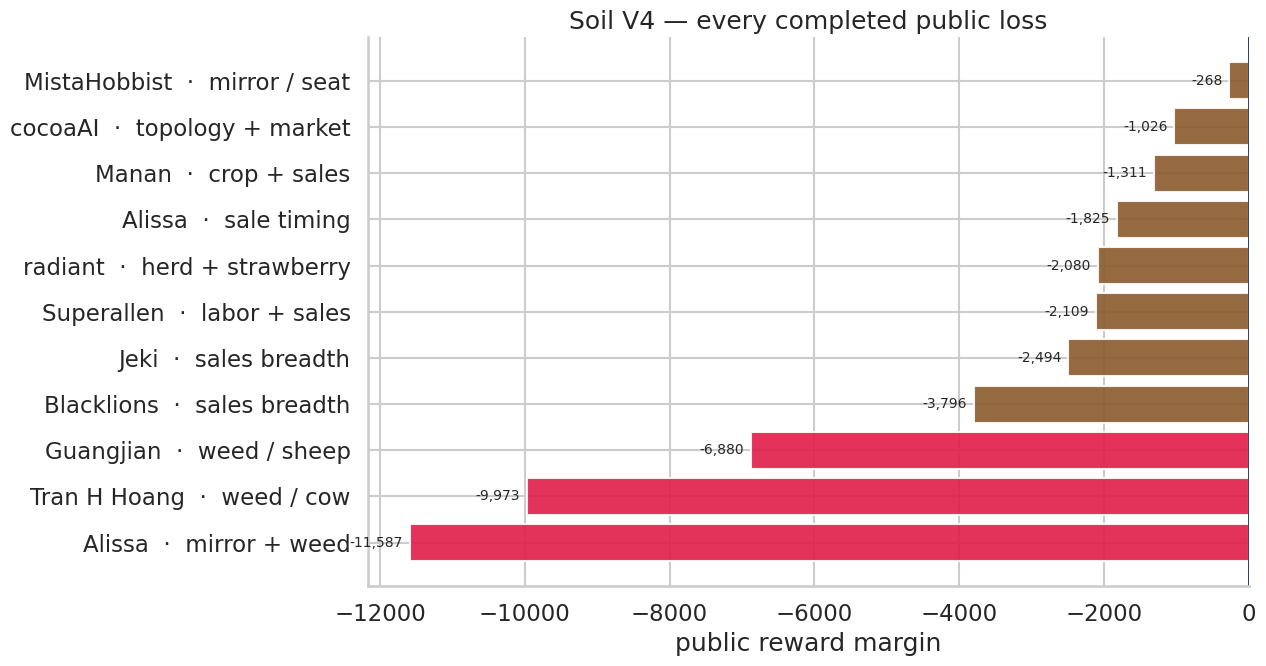

,episode,opponent,margin,family
0,89650345,Alissa,-11587,mirror + weed
1,89640248,Tran H Hoang,-9973,weed / cow
2,89639112,Guangjian,-6880,weed / sheep
3,89640242,Blacklions,-3796,sales breadth
4,89635727,Jeki,-2494,sales breadth
5,89649172,Superallen,-2109,labor + sales
6,89643054,radiant,-2080,herd + strawberry
7,89645297,Alissa,-1825,sale timing
8,89633468,Manan,-1311,crop + sales
9,89637987,cocoaAI,-1026,topology + market


In [2]:
LOSS_ROWS = [(89632336, 'MistaHobbist', -268, 'mirror / seat'), (89633468, 'Manan', -1311, 'crop + sales'), (89635727, 'Jeki', -2494, 'sales breadth'), (89637987, 'cocoaAI', -1026, 'topology + market'), (89639112, 'Guangjian', -6880, 'weed / sheep'), (89640242, 'Blacklions', -3796, 'sales breadth'), (89640248, 'Tran H Hoang', -9973, 'weed / cow'), (89643054, 'radiant', -2080, 'herd + strawberry'), (89645297, 'Alissa', -1825, 'sale timing'), (89649172, 'Superallen', -2109, 'labor + sales'), (89650345, 'Alissa', -11587, 'mirror + weed')]
loss = pd.DataFrame(LOSS_ROWS, columns=["episode", "opponent", "margin", "family"]).sort_values("margin")
labels = loss.opponent + "  ·  " + loss.family
fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(labels, loss.margin, color=[ROSE if "weed" in x else SOIL for x in loss.family], alpha=.9)
ax.axvline(0, color=NIGHT, lw=1.2); ax.bar_label(bars, labels=[f"{x:,.0f}" for x in loss.margin], padding=5, fontsize=10)
ax.set(title="Soil V4 — every completed public loss", xlabel="public reward margin")
sns.despine(); plt.tight_layout(); plt.show()
loss.reset_index(drop=True)


## 2. A failed build is a transaction, not a no-op

Four independent top-policy losses share the same visible sequence: a worker stands on `WEED`, asks for `BUILD_PASTURE`, and later tries to place an animal on the still-weedy coordinate. The accepted guard performs `DIG`, remembers only the worker and coordinate, then completes the pending pasture on the next turn.

No opponent name, leaderboard rank, episode id, hidden state, or random seed enters the rule. A short farmer-route shift is used only when the repair occurs in the last four hours of a day.


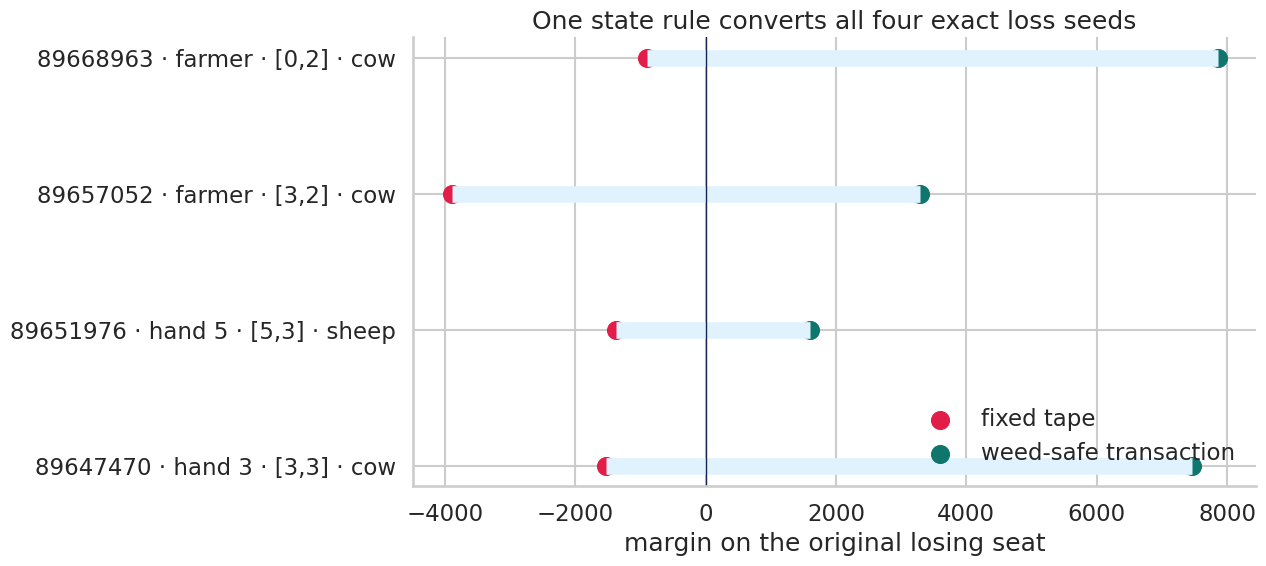

,episode,worker,coordinate,animal,raw,repaired,swing
0,89647470,hand 3,"[3,3]",cow,-1530,7465,8995
1,89651976,hand 5,"[5,3]",sheep,-1379,1600,2979
2,89657052,farmer,"[3,2]",cow,-3896,3293,7189
3,89668963,farmer,"[0,2]",cow,-905,7855,8760


In [3]:
REPAIR_ROWS = [(89647470, 'hand 3', '[3,3]', 'cow', -1530, 7465), (89651976, 'hand 5', '[5,3]', 'sheep', -1379, 1600), (89657052, 'farmer', '[3,2]', 'cow', -3896, 3293), (89668963, 'farmer', '[0,2]', 'cow', -905, 7855)]
repair = pd.DataFrame(REPAIR_ROWS, columns=["episode", "worker", "coordinate", "animal", "raw", "repaired"])
y = np.arange(len(repair)); fig, ax = plt.subplots(figsize=(13, 6))
ax.hlines(y, repair.raw, repair.repaired, color=MIST, lw=12)
ax.scatter(repair.raw, y, s=150, color=ROSE, label="fixed tape")
ax.scatter(repair.repaired, y, s=150, color=LEAF, label="weed-safe transaction")
ax.axvline(0, color=NIGHT, lw=1)
ax.set_yticks(y, [f"{r.episode} · {r.worker} · {r.coordinate} · {r.animal}" for r in repair.itertuples()])
ax.set(title="One state rule converts all four exact loss seeds", xlabel="margin on the original losing seat")
ax.legend(frameon=False, loc="lower right"); sns.despine(); plt.tight_layout(); plt.show()
repair.assign(swing=repair.repaired-repair.raw)


## 3. Why the whole schedule matters

The base behavior is distilled from **Tran H Hoang**, public episode **89674601**, seat 0, submission **55203154**. A component ablation on the same common schedule shows why copying a few market orders is unsafe: market, hands, and farmer routes are mutually coupled. Market plus hands gets partway there; the coherent three-channel schedule is the only version that sweeps all four fresh top traces.

Public action tapes are observations, not claims about an entrant's private implementation. The [Kaggriculture Episodes Index](https://www.kaggle.com/datasets/kaggle/kaggriculture-episodes-index) is the reproducibility surface; the state guards, terminal reconstruction, loss audit, validation, packaging, and presentation are this notebook's additions.


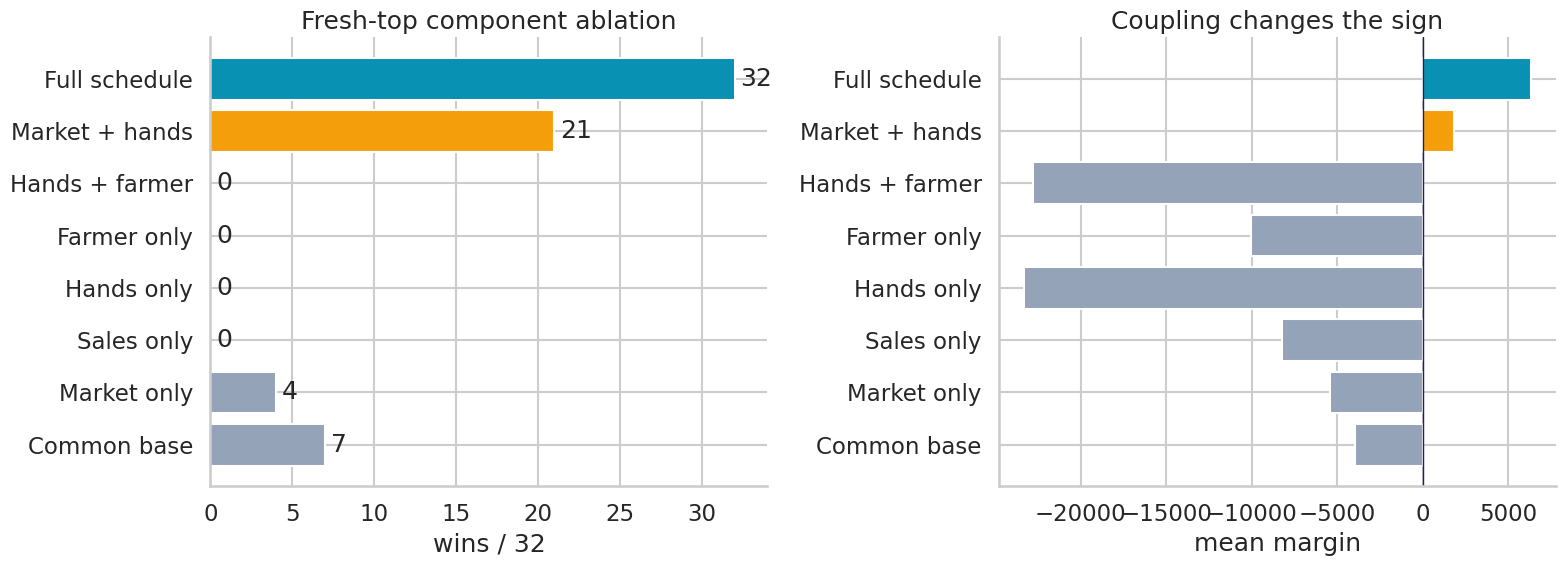

,component,wins,mean_margin
0,Common base,7,-3977.19
1,Market only,4,-5423.03
2,Sales only,0,-8246.62
3,Hands only,0,-23297.69
4,Farmer only,0,-10056.41
5,Hands + farmer,0,-22790.81
6,Market + hands,21,1824.25
7,Full schedule,32,6313.72


In [4]:
COMPONENT_ROWS = [('Common base', 7, -3977.19), ('Market only', 4, -5423.03), ('Sales only', 0, -8246.62), ('Hands only', 0, -23297.69), ('Farmer only', 0, -10056.41), ('Hands + farmer', 0, -22790.81), ('Market + hands', 21, 1824.25), ('Full schedule', 32, 6313.72)]
comp = pd.DataFrame(COMPONENT_ROWS, columns=["component", "wins", "mean_margin"])
palette = [RAIN if x == "Full schedule" else (SUN if x == "Market + hands" else "#94a3b8") for x in comp.component]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bars = axes[0].barh(comp.component, comp.wins, color=palette); axes[0].bar_label(bars, padding=4)
axes[0].set(xlim=(0,34), xlabel="wins / 32", title="Fresh-top component ablation")
axes[1].barh(comp.component, comp.mean_margin, color=palette); axes[1].axvline(0, color=NIGHT, lw=1)
axes[1].set(xlabel="mean margin", title="Coupling changes the sign")
sns.despine(); plt.tight_layout(); plt.show(); comp


## 4. The last four turns become observable

Two independent public Tran episodes from the same submission agree on 716 of 720 action dictionaries. Their only differences are terminal placements and sales. The reconstructed rule lets every worker place its highest-revenue carried product, aggregates those visible drops with the shed, and sells the ten highest-value product totals.


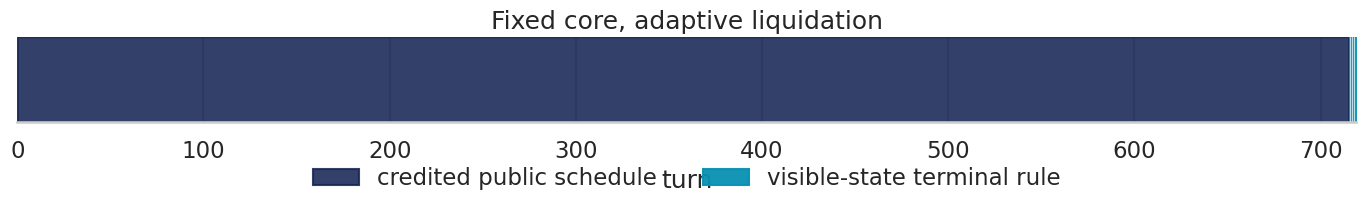

In [5]:
turns=np.arange(720); adaptive=turns>=716; fig,ax=plt.subplots(figsize=(14,2.8))
ax.fill_between(turns,0,1,where=~adaptive,color=NIGHT,alpha=.88,label="credited public schedule")
ax.fill_between(turns,0,1,where=adaptive,color=RAIN,alpha=.95,label="visible-state terminal rule")
for step in range(716,720): ax.axvline(step,color="white",lw=.8,alpha=.7)
ax.set(xlim=(0,719),ylim=(0,1),yticks=[],xlabel="turn",title="Fixed core, adaptive liquidation")
ax.legend(frameon=False,ncol=2,loc="upper center",bbox_to_anchor=(.5,-.28)); sns.despine(left=True); plt.tight_layout(); plt.show()


## 5. Promotion gates

Every row is a complete official-simulator matrix with 720 turns and `DONE` endpoints. The **post-freeze** row is the strict holdout: Ali and Chloe's public episode ended at 08:25 UTC, after this exact source had been frozen at 08:21 UTC.

These are local counterfactuals against preserved public tapes—not Kaggle public scores.


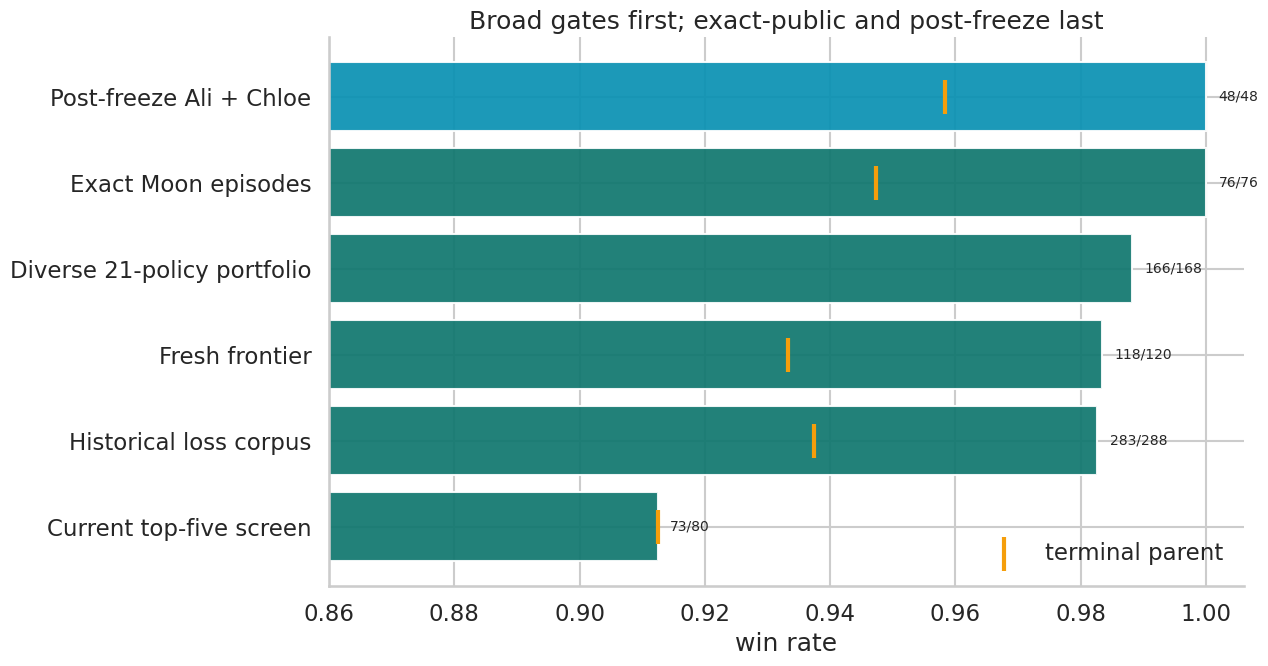

,gate,wins,games,parent_wins,definition
0,Historical loss corpus,283,288,270.0,preserved tapes
1,Diverse 21-policy portfolio,166,168,NaN,strategy diversity
2,Fresh frontier,118,120,112.0,current public
3,Exact Moon episodes,76,76,72.0,"exact seeds, both seats"
4,Post-freeze Ali + Chloe,48,48,46.0,ended after freeze
5,Current top-five screen,73,80,73.0,includes parent mirror


In [6]:
GATE_ROWS = [('Historical loss corpus', 283, 288, 270, 'preserved tapes'), ('Diverse 21-policy portfolio', 166, 168, None, 'strategy diversity'), ('Fresh frontier', 118, 120, 112, 'current public'), ('Exact Moon episodes', 76, 76, 72, 'exact seeds, both seats'), ('Post-freeze Ali + Chloe', 48, 48, 46, 'ended after freeze'), ('Current top-five screen', 73, 80, 73, 'includes parent mirror')]
gate = pd.DataFrame(GATE_ROWS, columns=["gate","wins","games","parent_wins","definition"])
gate["rate"]=gate.wins/gate.games; gate["parent_rate"]=gate.parent_wins/gate.games; ordered=gate.sort_values("rate")
y=np.arange(len(ordered)); fig,ax=plt.subplots(figsize=(13,7))
ax.barh(y,ordered.rate,color=[RAIN if "Post-freeze" in x else LEAF for x in ordered.gate],alpha=.92)
mask=ordered.parent_rate.notna(); ax.scatter(ordered.loc[mask,"parent_rate"],y[mask],marker="|",s=600,linewidths=3,color=SUN,label="terminal parent")
ax.set_yticks(y,ordered.gate); ax.set(xlim=(.86,1.006),xlabel="win rate",title="Broad gates first; exact-public and post-freeze last")
for i,r in enumerate(ordered.itertuples()): ax.text(r.rate+.002,i,f"{r.wins}/{r.games}",va="center",fontsize=10)
ax.legend(frameon=False,loc="lower right"); sns.despine(); plt.tight_layout(); plt.show(); gate.drop(columns=["rate","parent_rate"])


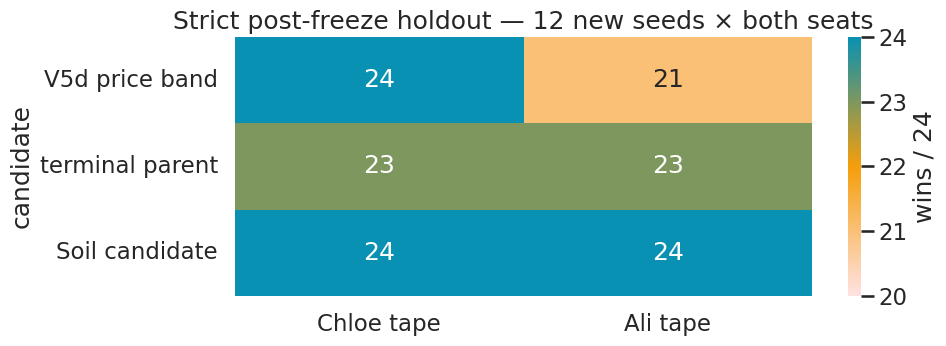

,Chloe tape,Ali tape
candidate,,
V5d price band,24,21
terminal parent,23,23
Soil candidate,24,24


In [7]:
holdout=pd.DataFrame({"candidate":["V5d price band","terminal parent","Soil candidate"],"Chloe tape":[24,23,24],"Ali tape":[21,23,24]}).set_index("candidate")
fig,ax=plt.subplots(figsize=(10,3.8)); cmap=LinearSegmentedColormap.from_list("soilrain",["#fee2e2",SUN,RAIN])
sns.heatmap(holdout,annot=True,fmt="g",vmin=20,vmax=24,cmap=cmap,cbar_kws={"label":"wins / 24"},ax=ax)
ax.set(title="Strict post-freeze holdout — 12 new seeds × both seats"); plt.tight_layout(); plt.show(); holdout


## 6. Write the agent

The standalone file embeds the credited public action tape, then adds only two observation-driven repairs: clear a visible weed before a requested pasture build, and liquidate visible terminal inventories. It has no internet, replay-file, dataset, model, opponent-identity, or notebook-global dependency at inference time.


In [8]:
AGENT_SOURCE = '"""Fixed public Tran H Hoang policy from episode 89674601, seat 0."""\nimport copy\n\nTRACE_ACTIONS = [{\'farmer\': [\'PASS\'], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 6], [\'BUY_SEED\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'BUILD_PASTURE\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'COW\', 1], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'COW\', 1]]}, {\'farmer\': [\'PLACE\', \'COW\'], \'hands\': [[\'BUILD_PASTURE\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'SHEEP\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'BUILD_PASTURE\'], [\'BUILD_PASTURE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PICKUP\', \'COW\', 2], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'SHEEP\', 1], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PLACE\', \'COW\'], [\'WATER\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'PLACE\', \'SHEEP\'], \'hands\': [[\'CARE\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'FEED\'], [\'PLANT\', \'MELON\'], [\'PLANT\', \'MELON\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'PLACE\', \'COW\'], [\'PLANT\', \'MELON\'], [\'PLANT\', \'MELON\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'CARE\'], [\'WEST\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'WEST\'], [\'PLANT\', \'MELON\'], [\'EAST\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'DROP\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'MELON\', 1], [\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'DROP\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'DROP\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 8]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MELON\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'MELON\', 3], [\'BUY_SEED\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'HARVEST\'], [\'FEED\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PLANT\', \'WHEAT\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'HARVEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_SEED\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'PLANT\', \'MELON\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'DROP\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 31], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'SHEEP\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'BUILD_PASTURE\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'BUILD_PASTURE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'COW\', 1], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'SHEEP\', 1], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'PLACE\', \'COW\'], [\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'CARE\'], [\'NORTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'PLACE\', \'SHEEP\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'CARE\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'DROP\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 6], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'DROP\'], [\'WATER\'], [\'WATER\'], [\'DROP\'], [\'WEST\']], \'market\': [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'EAST\'], [\'PASS\'], [\'WATER\']], \'market\': [[\'BUY_ANIMAL\', \'COW\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WEST\'], [\'NORTH\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'PASS\'], [\'WATER\'], [\'NORTH\'], [\'PASS\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 6]]}, {\'farmer\': [\'BUILD_PASTURE\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'PICKUP\', \'COW\', 1], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'BUY_LAND\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'COW\', 1], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 4], [\'BUY_SEED\', \'WHEAT\', 5], [\'SELL\', \'WHEAT\', 10]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'PLANT\', \'MELON\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'PLACE\', \'COW\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'DROP\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'WEST\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'DROP\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'CARE\'], [\'CARE\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'DROP\'], [\'WATER\'], [\'DROP\'], [\'NORTH\'], [\'BUILD_PASTURE\'], [\'CARE\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'CARE\'], [\'WEST\'], [\'PICKUP\', \'SHEEP\', 1], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'BUY_ANIMAL\', \'SHEEP\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'PLACE\', \'SHEEP\'], [\'NORTH\'], [\'BUILD_PASTURE\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'PICKUP\', \'SHEEP\', 1], [\'FEED\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'BUILD_PASTURE\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'BUILD_PASTURE\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'PLACE\', \'SHEEP\'], [\'PICKUP\', \'SHEEP\', 2], [\'PLANT\', \'WHEAT\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'CARE\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'CARE\'], [\'WATER\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'FEED\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'PASS\'], [\'PLACE\', \'SHEEP\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'FEED\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'CARE\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'PLACE\', \'SHEEP\'], [\'EAST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'CARE\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PLANT\', \'STRAWBERRY\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'DROP\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 17], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'PICKUP\', \'FERTILIZER\', 1], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'PICKUP\', \'WHEAT\', 1], [\'NORTH\'], [\'HARVEST\'], [\'DIG\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'DIG\'], [\'FERTILIZE\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'FERTILIZE\'], [\'DIG\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'BUILD_PASTURE\'], [\'WEST\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'PICKUP\', \'COW\', 1], \'hands\': [[\'WATER\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'DROP\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 9]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PLACE\', \'COW\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 5], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'HARVEST\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'MELON\', 6]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'WEST\'], [\'DROP\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'COW\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'PASS\'], [\'WEST\'], [\'HARVEST\'], [\'DROP\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'BUILD_PASTURE\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_LAND\']]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'PICKUP\', \'COW\', 1], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 9]]}, {\'farmer\': [\'PLANT\', \'STRAWBERRY\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'BUILD_PASTURE\'], [\'PASS\'], [\'SOUTH\'], [\'DROP\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': [[\'SELL\', \'MELON\', 6]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'SOUTH\'], [\'PICKUP\', \'COW\', 1], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'MELON\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MELON\', 18], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 15]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'COW\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 44]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'PLACE\', \'COW\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'WATER\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 11]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'SOUTH\'], [\'FEED\'], [\'PLANT\', \'MELON\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'PLACE\', \'COW\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'DROP\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'WATER\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 9]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'FEED\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 15]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 45]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 24]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 8]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'FERTILIZE\'], [\'EAST\'], [\'DROP\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'NORTH\'], [\'FEED\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'NORTH\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'DROP\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 12], [\'BUY_SEED\', \'STRAWBERRY\', 1], [\'SELL\', \'WHEAT\', 16]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'DROP\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'PLANT\', \'MELON\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'DROP\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'FERTILIZE\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\']], \'market\': [[\'SELL\', \'CARROT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 11]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'MILK\', 20]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'CARE\'], [\'EAST\'], [\'FERTILIZE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'CARE\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'MILK\', 4]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'DROP\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'DIG\'], [\'WEST\'], [\'FEED\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'PLANT\', \'MELON\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'DROP\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'DROP\'], [\'DIG\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 8]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'PLANT\', \'MELON\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'SELL\', \'WHEAT\', 9]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'EGG\', 1], [\'SELL\', \'FERTILIZER\', 5], [\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'HARVEST\'], [\'CARE\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 13]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'CARE\'], [\'CARE\'], [\'CARE\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'WEST\'], [\'FEED\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 6]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'SOUTH\'], [\'EAST\'], [\'CARE\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 4]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'FEED\'], [\'CARE\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'DROP\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'DROP\'], [\'HARVEST\'], [\'DIG\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 4], [\'SELL\', \'WOOL\', 6], [\'SELL\', \'WHEAT\', 8]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PASS\'], [\'WATER\'], [\'WEST\'], [\'DROP\'], [\'NORTH\'], [\'PASS\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'MELON\', 3]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'PASS\'], [\'NORTH\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'PASS\'], [\'WATER\'], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'WEST\'], [\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'DROP\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'PLANT\', \'MELON\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 20], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MELON\', 6]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'WATER\'], [\'WEST\'], [\'CARE\'], [\'CARE\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'FEED\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 9]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 6]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'FEED\'], [\'HARVEST\'], [\'FEED\'], [\'HARVEST\'], [\'WEST\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'MELON\'], [\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'DIG\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'DROP\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 7], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 22]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'PASS\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 10]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WOOL\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MILK\', 28]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 10]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'FEED\'], [\'WATER\'], [\'FEED\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'CARE\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'DIG\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'SELL\', \'WHEAT\', 14]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'FERTILIZE\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'DIG\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MILK\', 9], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'HARVEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'HARVEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'WATER\'], [\'CARE\'], [\'FERTILIZE\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'WATER\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 12]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'DROP\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'DROP\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 5], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'DROP\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\'], [\'CARE\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 15]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'FEED\'], [\'CARE\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'DROP\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'DIG\'], [\'PASS\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'WHEAT\'], [\'PASS\'], [\'FERTILIZE\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'DROP\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'PASS\'], [\'FERTILIZE\']], \'market\': [[\'SELL\', \'MILK\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 8], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 12]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'FEED\'], [\'WEST\'], [\'HARVEST\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'FEED\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'CARE\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'CARROT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'CARE\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'FEED\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 20]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 9]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 9]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'CARE\']], \'market\': [[\'SELL\', \'WHEAT\', 8]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 2], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'FERTILIZE\']], \'market\': [[\'SELL\', \'MILK\', 12]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'DROP\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 6]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 6], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 17]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'WATER\'], [\'FEED\'], [\'CARE\'], [\'EAST\'], [\'CARE\'], [\'CARE\'], [\'SOUTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 20]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 12]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 12]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FERTILIZE\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'FERTILIZE\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'DROP\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 7], [\'SELL\', \'WHEAT\', 19], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'STRAWBERRY\', 9]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'HARVEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'SOUTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'CARE\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'CARE\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'FEED\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'EAST\'], [\'DROP\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'CARROT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 12], [\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'DROP\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'WATER\'], [\'WEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 7]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'FEED\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'DROP\'], [\'WEST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'PASS\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'FERTILIZE\'], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'DROP\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'PASS\'], [\'WEST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'SELL\', \'MELON\', 8]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'PASS\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'WHEAT\', 16], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'STRAWBERRY\', 14]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'FERTILIZE\'], [\'FEED\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'DIG\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'HARVEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FERTILIZE\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 12]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'FERTILIZE\'], [\'EAST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'DIG\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FERTILIZE\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 2]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'FEED\'], [\'WATER\'], [\'FERTILIZE\'], [\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'MELON\', 6], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'WEST\'], [\'DROP\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'DROP\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 3], [\'EAST\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FERTILIZE\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'WATER\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 20]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'FERTILIZE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'WATER\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'DROP\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MELON\', 3]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'DROP\'], [\'FERTILIZE\'], [\'WATER\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 11], [\'SELL\', \'MILK\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'DROP\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'PASS\'], [\'DROP\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 14]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 8], [\'SELL\', \'WOOL\', 12]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'PASS\'], [\'PASS\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WOOL\', 8], [\'SELL\', \'WHEAT\', 14]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2]], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 12]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'CARE\'], [\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'HARVEST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'CARE\'], [\'WEST\'], [\'HARVEST\'], [\'FEED\'], [\'FERTILIZE\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 14]]}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'DROP\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'WHEAT\', 16], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'HARVEST\'], [\'WEST\'], [\'DROP\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'WOOL\', 5], [\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'DROP\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 2], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'DROP\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 3], [\'SELL\', \'STRAWBERRY\', 20]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 5], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'DROP\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 7], [\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MILK\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 7], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'STRAWBERRY\', 19]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'STRAWBERRY\', 28]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'WATER\'], [\'EAST\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'HARVEST\'], [\'CARE\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 12]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 11]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'SOUTH\'], [\'CARE\'], [\'EAST\'], [\'WATER\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'DROP\'], [\'HARVEST\'], [\'WATER\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 11]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WATER\'], [\'DIG\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'DIG\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 1], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'DROP\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'DIG\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'DROP\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'DIG\'], [\'EAST\'], [\'HARVEST\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'DROP\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 11], [\'SELL\', \'FERTILIZER\', 14], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 12]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'SOUTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'DIG\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'FEED\'], [\'WATER\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'HARVEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'WEST\'], [\'DIG\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'DIG\'], [\'FEED\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 2], [\'SELL\', \'WHEAT\', 12]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 10]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'EGG\', 5], [\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'DIG\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'DROP\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FERTILIZE\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'DIG\'], [\'PASS\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'DROP\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'MILK\', 2], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'PASS\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 8], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'FERTILIZER\', 4], \'hands\': [[\'PICKUP\', \'WHEAT\', 7], [\'PICKUP\', \'FERTILIZER\', 3], [\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'CARE\'], [\'WEST\']], \'market\': [[\'HIRE\'], [\'BUY_SEED\', \'WHEAT\', 30], [\'SELL\', \'MILK\', 30], [\'SELL\', \'MELON\', 6]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'HARVEST\'], [\'PLANT\', \'WHEAT\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'WATER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'CARE\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'CARE\'], [\'SOUTH\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'HARVEST\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'PLANT\', \'WHEAT\'], [\'HARVEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'DIG\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'DIG\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'DIG\'], [\'WEST\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'WHEAT\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'WHEAT\'], [\'EAST\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'FERTILIZE\'], [\'PLANT\', \'WHEAT\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'HARVEST\'], [\'CARE\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 20]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'DIG\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 8], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'FERTILIZER\', 4], \'hands\': [[\'PICKUP\', \'WHEAT\', 7], [\'PICKUP\', \'FERTILIZER\', 4], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'CARE\']], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WOOL\', 20], [\'SELL\', \'FERTILIZER\', 8], [\'SELL\', \'STRAWBERRY\', 15], [\'SELL\', \'MELON\', 6]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'PLANT\', \'WHEAT\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'CARE\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'CARE\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'MILK\', 10]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'PLANT\', \'WHEAT\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'PLANT\', \'WHEAT\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'FERTILIZE\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'FERTILIZE\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'EAST\'], [\'FERTILIZE\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'FERTILIZE\'], [\'PASS\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'MILK\', 15]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PASS\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'FERTILIZE\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 8], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'FERTILIZER\', 4], \'hands\': [[\'PICKUP\', \'WHEAT\', 7], [\'PICKUP\', \'FERTILIZER\', 4], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'HIRE\'], [\'SELL\', \'MELON\', 2], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'MILK\', 4]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'FERTILIZE\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'FERTILIZE\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'MILK\', 12]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'FERTILIZE\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 23]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 14]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 20], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'EAST\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 15]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'FERTILIZE\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 13], [\'SELL\', \'FERTILIZER\', 7], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'HARVEST\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'WOOL\', 12]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 9], [\'SELL\', \'WHEAT\', 36]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'PASS\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'DROP\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'DROP\'], [\'NORTH\'], [\'DROP\'], [\'DROP\'], [\'SOUTH\'], [\'DROP\'], [\'PASS\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 20], [\'SELL\', \'MILK\', 12], [\'SELL\', \'FERTILIZER\', 10]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'DROP\'], [\'SOUTH\'], [\'PASS\'], [\'DROP\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'WHEAT\', 40], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 20]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'MELON\', 10], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLACE\', \'WOOL\', 4], [\'PLACE\', \'WHEAT\', 7], [\'PASS\'], [\'PLACE\', \'WOOL\', 4], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'WOOL\', 4], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'WHEAT\', 7]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLACE\', \'WHEAT\', 5], [\'PLACE\', \'STRAWBERRY\', 3], [\'PASS\'], [\'PLACE\', \'WHEAT\', 3], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'WHEAT\', 5], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLACE\', \'FERTILIZER\', 1], [\'PLACE\', \'MILK\', 3], [\'PASS\'], [\'PLACE\', \'FERTILIZER\', 2], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'FERTILIZER\', 1], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'MILK\', 2], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'MILK\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'MILK\', 2], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'MILK\', 2]]}]\n\n\ndef _TRAN_BASE_AGENT(obs, config=None):\n    step = min(int(obs.get("step", 0) or 0), len(TRACE_ACTIONS) - 1)\n    return copy.deepcopy(TRACE_ACTIONS[step])\n\n\n_TRAN_TERMINAL_PRODUCTS = {\n    "WHEAT", "CARROT", "TOMATO", "STRAWBERRY", "MELON",\n    "EGG", "MILK", "WOOL", "FERTILIZER",\n}\n\n\ndef _best_terminal_item(inventory, prices):\n    choices = [\n        (int(prices.get(item, 0) or 0) * int(quantity or 0),\n         int(prices.get(item, 0) or 0), int(quantity or 0), item)\n        for item, quantity in (inventory or {}).items()\n        if item in _TRAN_TERMINAL_PRODUCTS and int(quantity or 0) > 0\n    ]\n    return max(choices, default=None)\n\n\ndef _TRAN_TERMINAL_AGENT(obs, config=None):\n    action = _TRAN_BASE_AGENT(obs, config)\n    step = int(obs.get("step", 0) or 0)\n    if step < 716:\n        return action\n\n    private = obs.get("private", {}) or {}\n    inventories = private.get("inventories", []) or []\n    shed = private.get("shed", {}) or {}\n    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})\n    player = int(obs.get("player", 0) or 0)\n    farms = obs.get("farms", []) or []\n    farm = farms[player] if 0 <= player < len(farms) else {}\n    hand_count = len(farm.get("hands", []) or [])\n\n    placed = {}\n    farmer_choice = _best_terminal_item(\n        inventories[0] if inventories else {}, prices\n    )\n    action["farmer"] = ["PASS"]\n    if farmer_choice is not None:\n        _, _, quantity, item = farmer_choice\n        action["farmer"] = ["PLACE", item, quantity]\n        placed[item] = placed.get(item, 0) + quantity\n\n    hand_actions = []\n    for index in range(hand_count):\n        inventory = inventories[index + 1] if index + 1 < len(inventories) else {}\n        choice = _best_terminal_item(inventory, prices)\n        if choice is None:\n            hand_actions.append(["PASS"])\n            continue\n        _, _, quantity, item = choice\n        hand_actions.append(["PLACE", item, quantity])\n        placed[item] = placed.get(item, 0) + quantity\n    action["hands"] = hand_actions\n\n    sale_totals = {\n        item: int(shed.get(item, 0) or 0) + int(placed.get(item, 0) or 0)\n        for item in _TRAN_TERMINAL_PRODUCTS\n        if int(shed.get(item, 0) or 0) + int(placed.get(item, 0) or 0) > 0\n    }\n    ordered = sorted(\n        sale_totals,\n        key=lambda item: (\n            int(prices.get(item, 0) or 0) * sale_totals[item],\n            int(prices.get(item, 0) or 0),\n            sale_totals[item],\n            item,\n        ),\n        reverse=True,\n    )\n    action["market"] = [["SELL", item, sale_totals[item]] for item in ordered[:10]]\n    return action\n\n\n_TRAN_PENDING_PASTURE = None\n_TRAN_FARMER_SHIFT_END = None\n\n\ndef _tran_tile_at(farm, position):\n    if not isinstance(position, (list, tuple)) or len(position) != 2:\n        return "OUT_OF_BOUNDS"\n    column, row = map(int, position)\n    tiles = farm.get("tiles", []) or []\n    if not (0 <= row < len(tiles) and 0 <= column < len(tiles[row])):\n        return "OUT_OF_BOUNDS"\n    return tiles[row][column]\n\n\ndef agent(obs, config=None):\n    global _TRAN_PENDING_PASTURE, _TRAN_FARMER_SHIFT_END\n\n    step = int(obs.get("step", 0) or 0)\n    if step == 0:\n        _TRAN_PENDING_PASTURE = None\n        _TRAN_FARMER_SHIFT_END = None\n    action = copy.deepcopy(_TRAN_TERMINAL_AGENT(obs, config))\n    if step >= 716:\n        return action\n\n    player = int(obs.get("player", 0) or 0)\n    farms = obs.get("farms", []) or []\n    farm = farms[player] if 0 <= player < len(farms) else None\n    if not isinstance(farm, dict):\n        return action\n\n    hands = farm.get("hands", []) or []\n    hand_actions = action.get("hands", []) or []\n\n    # If a late-day farmer DIG displaces the public tape by one hour, retain\n    # its prior route only until that day ends.  The next day resumes the tape.\n    if _TRAN_FARMER_SHIFT_END is not None:\n        if step <= _TRAN_FARMER_SHIFT_END:\n            previous = TRACE_ACTIONS[max(0, step - 1)] or {}\n            action["farmer"] = copy.deepcopy(previous.get("farmer") or [])\n        else:\n            _TRAN_FARMER_SHIFT_END = None\n\n    if _TRAN_PENDING_PASTURE is not None:\n        channel, actor, position, expected_step = _TRAN_PENDING_PASTURE\n        if step == expected_step:\n            if channel == "farmer":\n                current = farm.get("farmer")\n                if list(current or []) == position and _tran_tile_at(farm, current) is None:\n                    action["farmer"] = ["BUILD_PASTURE"]\n            elif 0 <= actor < len(hands) and actor < len(hand_actions):\n                if list(hands[actor]) == position and _tran_tile_at(farm, hands[actor]) is None:\n                    hand_actions[actor] = ["BUILD_PASTURE"]\n        _TRAN_PENDING_PASTURE = None\n\n    farmer_position = farm.get("farmer")\n    farmer_tile = _tran_tile_at(farm, farmer_position)\n    if (\n        action.get("farmer") == ["BUILD_PASTURE"]\n        and isinstance(farmer_tile, dict)\n        and farmer_tile.get("kind") == "WEED"\n    ):\n        action["farmer"] = ["DIG"]\n        if step % 24 >= 20:\n            _TRAN_FARMER_SHIFT_END = (step // 24 + 1) * 24 - 1\n        _TRAN_PENDING_PASTURE = (\n            "farmer", None, list(farmer_position), step + 1\n        )\n\n    for actor, requested in enumerate(hand_actions[: len(hands)]):\n        if _TRAN_PENDING_PASTURE is not None:\n            break\n        if requested != ["BUILD_PASTURE"]:\n            continue\n        tile = _tran_tile_at(farm, hands[actor])\n        if isinstance(tile, dict) and tile.get("kind") == "WEED":\n            hand_actions[actor] = ["DIG"]\n            _TRAN_PENDING_PASTURE = (\n                "hands", actor, list(hands[actor]), step + 1\n            )\n            break\n    action["hands"] = hand_actions\n    return action\n'

EXPECTED_SHA256="c3be7447f79a1c4e0a9fa537b9fbd2eb7ae1a199a09690e7dfdc15da1cb0b5a4"
source_bytes=AGENT_SOURCE.encode("utf-8")
assert hashlib.sha256(source_bytes).hexdigest()==EXPECTED_SHA256
compile(AGENT_SOURCE,"main.py","exec")
MAIN_PATH=Path.cwd()/"main.py"; MAIN_PATH.write_text(AGENT_SOURCE,encoding="utf-8")
print("main.py",len(source_bytes),"bytes",EXPECTED_SHA256[:16]+"…")


main.py 142690 bytes c3be7447f79a1c4e…


### Live execution proof

The written file is loaded by the official environment, not by the notebook namespace. Both player positions must reach `DONE` after all 720 turns.


In [9]:
rows=[]; representative=None
for side in (0,1):
    agents=[str(MAIN_PATH),"starter"] if side==0 else ["starter",str(MAIN_PATH)]
    env=make("kaggriculture",configuration={"episodeSteps":720,"seed":20260803},debug=False); env.run(agents); final=env.steps[-1]
    assert len(env.steps)==720 and final[side].status=="DONE" and final[1-side].status=="DONE"
    rows.append({"side":side,"candidate_reward":float(final[side].reward or 0),"starter_reward":float(final[1-side].reward or 0),"margin":float(final[side].reward or 0)-float(final[1-side].reward or 0),"steps":len(env.steps),"status":final[side].status})
    if side==0: representative=env
live=pd.DataFrame(rows); assert (live.margin>0).all(); live


,side,candidate_reward,starter_reward,margin,steps,status
0,0,177919.0,3507.0,174412.0,720,DONE
1,1,182988.0,3507.0,179481.0,720,DONE


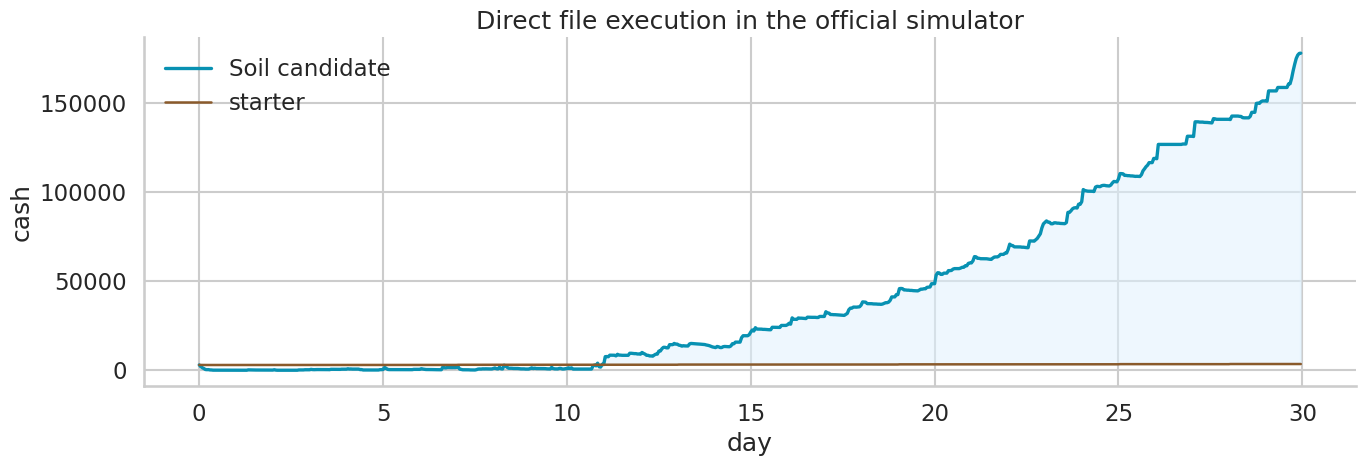

In [10]:
hours=np.arange(len(representative.steps)); a=[float(x[0].observation.farms[0].money) for x in representative.steps]; b=[float(x[0].observation.farms[1].money) for x in representative.steps]
fig,ax=plt.subplots(figsize=(14,5)); ax.plot(hours/24,a,color=RAIN,lw=2.4,label="Soil candidate"); ax.plot(hours/24,b,color=SOIL,lw=1.8,label="starter")
ax.fill_between(hours/24,b,a,where=np.asarray(a)>=np.asarray(b),color=MIST,alpha=.55); ax.set(xlabel="day",ylabel="cash",title="Direct file execution in the official simulator")
ax.legend(frameon=False); sns.despine(); plt.tight_layout(); plt.show()


## 7. Package integrity

The competition bundle contains exactly one root file, `main.py`. Submit `submission.tar.gz` from this version's **Submit to competition** button.


In [11]:
BUNDLE_PATH=Path.cwd()/"submission.tar.gz"
with tarfile.open(BUNDLE_PATH,"w:gz") as bundle: bundle.add(MAIN_PATH,arcname="main.py")
with tarfile.open(BUNDLE_PATH,"r:gz") as bundle:
    names=bundle.getnames(); handle=bundle.extractfile("main.py"); payload=handle.read() if handle else b""
assert names==["main.py"] and hashlib.sha256(payload).hexdigest()==EXPECTED_SHA256
{"bundle":BUNDLE_PATH.name,"members":names,"source_sha256":EXPECTED_SHA256,"source_bytes":len(payload),"live_sides_done":int((live.status=="DONE").sum())}


{'bundle': 'submission.tar.gz',
 'members': ['main.py'],
 'source_sha256': 'c3be7447f79a1c4e0a9fa537b9fbd2eb7ae1a199a09690e7dfdc15da1cb0b5a4',
 'source_bytes': 142690,
 'live_sides_done': 2}

---

## Where to improve next

- **Keep topology observable.** Generalize only from failed commands visible on the candidate's farm.
- **Test channels together.** Market orders without their matching work schedule reverse the benefit.
- **Freeze before holdout.** Preserve a source hash, then collect later public episodes.
- **Separate cash from match margin.** Inspect both endpoints instead of hiding interactions in an average.

The agent is immediately runnable, but the loss-first workflow is the more reusable starting point.
